# Distribution of CMEs for varying ejection-angle spread

(see point 6 in the README)

The overall CME viewing-angle distribution $\rho_\beta(\beta)$ derived in `CME_distribution.ipynb`
assumed that CMEs are ejected close to radially: the angle $\theta'$ between the CME and the local
zenith is drawn from a Gaussian centred on the zenith (`loc=0`) with a spread (standard deviation,
`scale`) of $0.2$ rad ($\approx 11.5$°). Observationally, the *scatter* in the ejection angle of solar
CMEs around the zenith is usually taken to be of order 20-30°, and this spread is not well constrained
for other stars.

Here we repeat the calculation of `CME_distribution.ipynb` for the solar (Rice-fitted) active-region
distribution, keeping the ejection-angle distribution centred on the zenith (`loc=0`, exactly as in
`CME_distribution.ipynb`) but varying its spread (`scale`) to 10°, 20°, 23°, 60° and 90°, to see how
sensitive the resulting $\beta$ distribution is to this assumption.

import dependencies

In [1]:
import numpy as np
import scipy.special as sc
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm
from scipy.interpolate import make_interp_spline
from pathlib import Path


Define the 3D distribution as a function of latitude $\alpha$.
(obtained in experimental_flare_distribution.ipynb, same fit as used in CME_distribution.ipynb)

Text(0, 0.5, 'probability density per unit area')

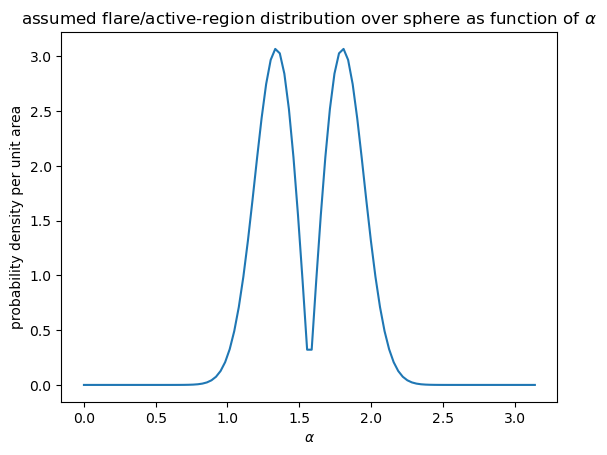

In [2]:
# general distribution of active regions per unit area (Sun, Rice-distribution fit)
def rice_dist(x, sigma, nu):
    x = np.abs(x)
    return x / sigma**2 * np.exp( - (x**2 + nu **2 ) / (2 * sigma **2)) * sc.iv(0, (x * nu / sigma**2))

sigma_fit, nu_fit = (9.02769086 / 180 * np.pi, 10.48768514 / 180 * np.pi)
Rn = 1
def rho(alpha, err=0.01):
    return rice_dist(np.pi / 2 - alpha, sigma_fit, nu_fit)  / (np.sin(alpha) + err) / Rn
            # fit of dist when integrated over phi and absolute value so accounting for that

alpha = np.linspace(0, np.pi, 100)
plt.plot(alpha, rho(alpha))
plt.title(r"assumed flare/active-region distribution over sphere as function of $\alpha$")
plt.xlabel(r"$\alpha$")
plt.ylabel('probability density per unit area')


## CME ejection-angle distribution for a given spread

As in `CME_distribution.ipynb`, the distribution of CMEs as a function of the angle $\theta'$ with the
zenith is assumed Gaussian and centred on the zenith (`loc=0`,
`rho_CME(theta2, loc=0, scale=0.2)`); here we keep that centring fixed and instead vary the *spread*
(`scale`, i.e. the standard deviation of the ejection angle around the zenith) as the free parameter
per scenario. Each distribution is properly normalised over the hemisphere $\theta' \in [0, \pi/2]$.

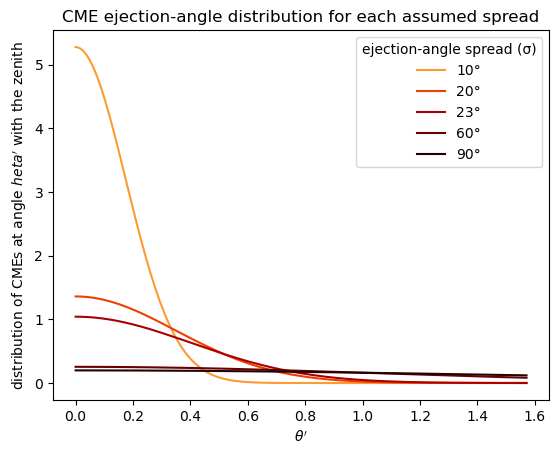

In [3]:
def make_rho_CME(scale, loc=0):
    """Build a normalised CME ejection-angle distribution centred on the zenith (loc=0) with the given spread `scale` (radians)."""
    def rho_CME_unnorm(theta2):
        return norm.pdf(theta2, loc, scale)

    f = lambda theta2: rho_CME_unnorm(theta2) * np.sin(theta2) * 2 * np.pi
    N = quad(f, 0, np.pi / 2)[0]

    def rho_CME(theta2):
        return rho_CME_unnorm(theta2) / N
    return rho_CME


output_spreads_deg = [10, 20, 23, 60, 90]
rho_CME_of_angle = {deg: make_rho_CME(deg / 180 * np.pi) for deg in output_spreads_deg}

cmap = plt.get_cmap("gist_heat_r")
colors = cmap(np.linspace(0.2, 0.9, len(output_spreads_deg)))
color_of_angle = dict(zip(output_spreads_deg, colors))

T = np.linspace(0, np.pi / 2, 200)
for deg, rho_CME in rho_CME_of_angle.items():
    plt.plot(T, [rho_CME(t) for t in T], color=color_of_angle[deg], label=f"{deg}°")
plt.xlabel(r"$\theta'$")
plt.ylabel("distribution of CMEs at angle $\theta'$ with the zenith")
plt.title("CME ejection-angle distribution for each assumed spread")
plt.legend(title="ejection-angle spread (σ)")


## Distribution of CMEs in viewing angle $\beta$ for given $\tau$

We reuse the same reduction of the four-fold integral over $(\theta, \phi, \theta', \phi')$ derived in
`CME_distribution.ipynb` (the $\phi'$ integral is done analytically against the delta function):

\begin{equation}
    \rho_\beta(\beta) = \frac{1}{N} \int_{[0,\pi] \times [0,2\pi] \times [0,\pi] }d\theta d\phi d\theta'
    \rho (\alpha(\theta, \phi))   \rho^{CME}(\theta')  \frac{|\sin\beta|}{2\,|\sin\theta\sin\theta'\sin\phi'(\theta, \theta', \beta)|}
\end{equation}

(this corrects an earlier version of this formula that had $\sin\phi'$ in the numerator and $|\sin\beta|$
in the denominator instead — see the "Correction" note in `CME_distribution.ipynb` for the full
derivation and the brute-force Monte Carlo cross-check).

`CME_distribution.ipynb` evaluates this with `scipy.integrate.nquad`, which needs a low tolerance
(`epsrel=0.05`) and is *very* slow — the corrected $1/\sin\phi'$ form has a genuine, if integrable,
singularity at the domain boundary, so a single `nquad` evaluation can exceed two minutes. Since we need
to repeat the full calculation for 5 different ejection-angle scenarios (instead of 1), we instead use
the vectorised Monte Carlo estimator that the original notebook already mentions as the fast
alternative: we draw uniform samples of $(\theta, \phi, \theta')$ once per $\tau$ and evaluate the
integrand for every $\beta$ at once.

In [4]:
def get_alpha(tau, theta, phi):
    return np.arccos( np.sin( tau ) * np.sin(theta) * np.cos(phi) + np.cos(tau) * np.cos(theta))


def mc_rho_betas(betas, tau, rho_CME, n=3_000_000, seed=0):
    """Monte Carlo estimate of rho_beta(beta, tau) for every beta in `betas`, for a given rho_CME."""
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0, np.pi, n)[:, None]
    phi = rng.uniform(0, 2 * np.pi, n)[:, None]
    theta2 = rng.uniform(0, np.pi / 2, n)[:, None]
    betas = np.asarray(betas)[None, :]

    alpha = get_alpha(tau, theta, phi)

    denom = np.sin(theta) * np.sin(theta2)
    cosphi2 = (np.cos(betas) - np.cos(theta) * np.cos(theta2)) / denom
    valid = np.abs(cosphi2) <= 1
    sinphi2 = np.where(valid, np.sqrt(np.clip(1 - cosphi2**2, 0, None)), 0.0)

    mask = (betas >= theta - theta2) & (betas <= theta + theta2) & (sinphi2 > 1e-6)
    safe_sinphi2 = np.where(mask, sinphi2, 1.0)
    # corrected: sin(phi') in the denominator (was the numerator); sin(theta), sin(theta2)
    # cancel against the measure and no longer appear. See CME_distribution.ipynb for the derivation.
    integrand = np.where(mask, rho(alpha) * rho_CME(theta2) / safe_sinphi2, 0.0)

    volume = np.pi * (2 * np.pi) * (np.pi / 2)   # volume of the (theta, phi, theta2) sampling box
    mean_val = integrand.mean(axis=0) * volume
    # corrected: multiply by |sin(beta)| (was dividing by it)
    return mean_val * np.abs(np.sin(betas.ravel())) / 2


betas = np.linspace(0, np.pi / 2, 20)
Taus = np.linspace(0, np.pi / 2, 5)
x = np.linspace(0, np.pi, 300)

In [5]:
def get_or_create_data(name, compute_fn):
    filename = f'calculations/{name}.npy'
    file_path = Path(filename)

    if file_path.exists():
        print(f"File '{filename}' found.")
        data = np.load(filename)
    else:
        print(f"File '{filename}' not found. Creating new data...")
        data = compute_fn()
        np.save(filename, data)
        print(f"Data saved to '{filename}'.")

    return data


def speed2beta(v):
    return np.arccos(v / 600)

def beta2speed(beta):
    return np.cos(beta) * 600


def plotting_(dens, taus, cmap_name="gist_heat_r"):
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(0.2, 0.9, len(taus)))
    for c, (i, d) in zip(colors, enumerate(dens)):
        smooth_curve = make_interp_spline(betas, d / (np.average(d) * np.pi))(x)
        plt.plot(x, smooth_curve, color=c, label=fr"$\tau=${round(taus[i]/np.pi*180)}°")
    plt.plot(x, np.sin(x) / 2, "--", color='tab:red', label="mean")

    plt.legend()
    plt.xticks(np.linspace(0, np.pi / 2, 7), range(0, 91, 15))
    ax = plt.gca()
    secax = ax.secondary_xaxis('top', functions=(beta2speed, speed2beta))
    secax.set_xlabel(r'$\cos \beta \times 600$ km/s ')
    plt.xlabel(r"$\beta$ [°]")
    plt.ylabel(r"density []")
    plt.xlim(0, np.pi / 2)
    plt.ylim(0, 1)


### Run the calculation for each ejection-angle spread

For every assumed spread we compute $\rho_\beta(\beta)$ across the same 5 stellar
orientations $\tau$ used in `CME_distribution.ipynb`, and cache the result to `calculations/` so the
notebook does not need to redo the (still fairly expensive) sampling on every run.

File 'calculations/output_angle_10deg.npy' not found. Creating new data...


Data saved to 'calculations/output_angle_10deg.npy'.


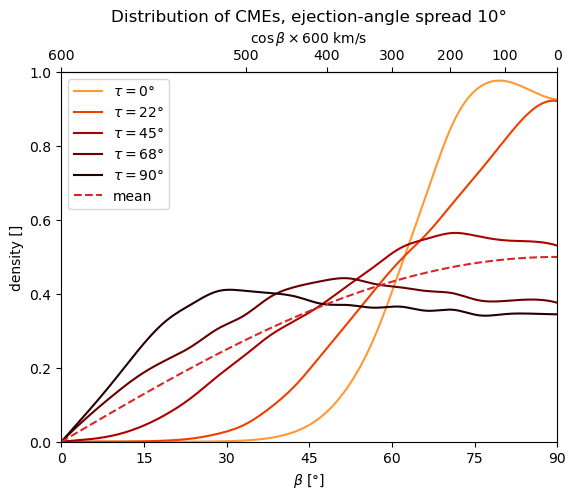

File 'calculations/output_angle_20deg.npy' not found. Creating new data...


Data saved to 'calculations/output_angle_20deg.npy'.


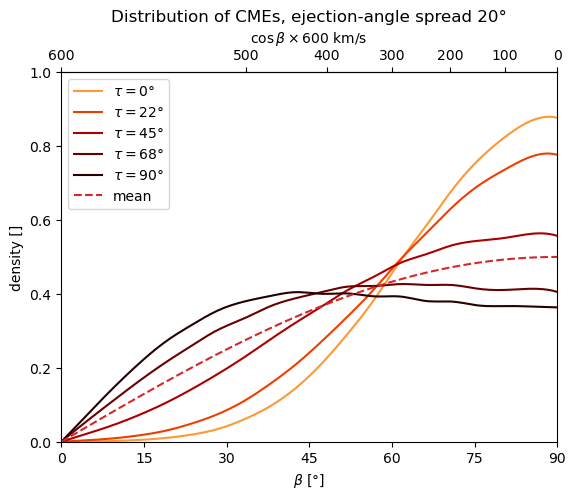

File 'calculations/output_angle_23deg.npy' not found. Creating new data...


Data saved to 'calculations/output_angle_23deg.npy'.


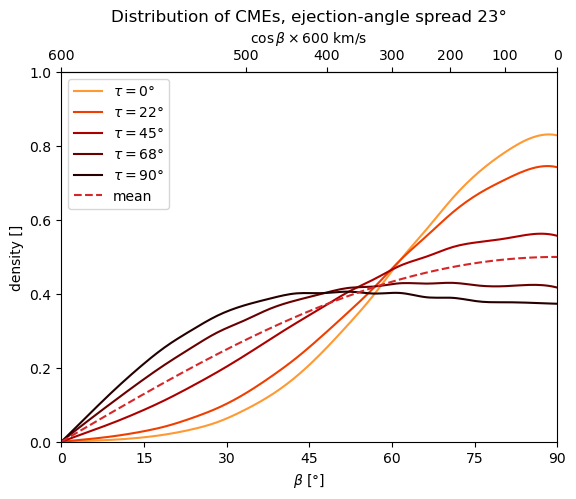

File 'calculations/output_angle_60deg.npy' not found. Creating new data...


Data saved to 'calculations/output_angle_60deg.npy'.


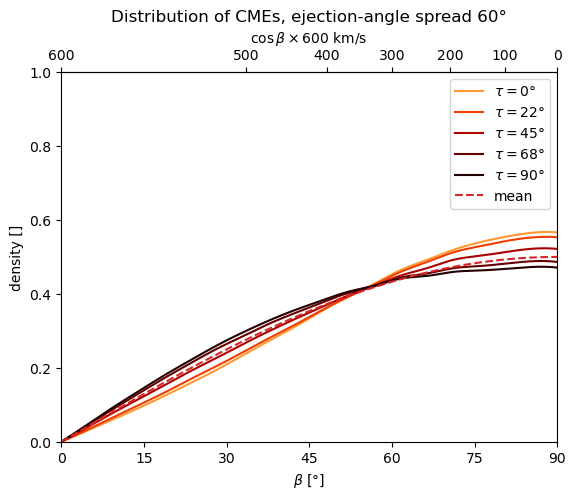

File 'calculations/output_angle_90deg.npy' not found. Creating new data...


Data saved to 'calculations/output_angle_90deg.npy'.


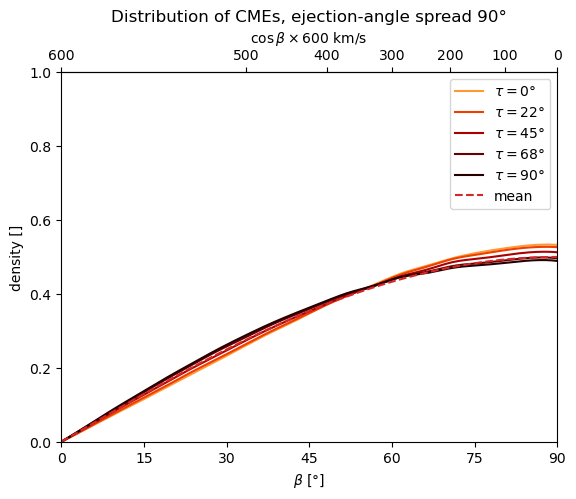

In [6]:
dens_of_angle = {}

for deg in output_spreads_deg:
    rho_CME = rho_CME_of_angle[deg]

    def compute_fn(rho_CME=rho_CME):
        return np.array([mc_rho_betas(betas, tau, rho_CME) for tau in Taus])

    dens = get_or_create_data(f"output_angle_{deg}deg", compute_fn)
    dens_of_angle[deg] = dens

    plotting_(dens, Taus)
    plt.title(f"Distribution of CMEs, ejection-angle spread {deg}°")
    plt.show()


## Comparing ejection-angle spreads at fixed stellar orientation

To isolate the effect of the ejection-angle-spread assumption from the effect of the (unknown) stellar
orientation $\tau$, we now fix $\tau=45$° (the middle sample of `Taus`) and overlay the resulting
$\beta$ distribution for every spread. We also add the default scenario ($\sigma=11.5$°,
`scale=0.2` rad) already computed and cached as `sundist.npy` in `CME_distribution.ipynb` as a
reference — the shape comparison is valid even though it was computed with the slower `nquad` method,
since `plotting_` normalises every curve by its own average.

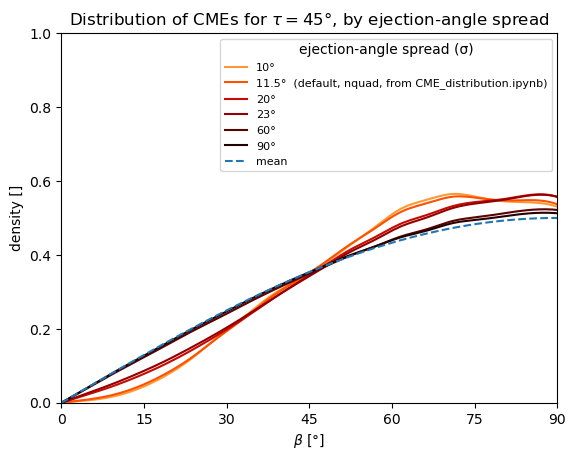

In [7]:
tau_index = 2   # Taus[2] == pi/4 == 45 degrees
sundist = np.load('calculations/sundist.npy')

default_spread_deg = round(0.2 * 180 / np.pi, 1)   # scale=0.2 rad, as in CME_distribution.ipynb
reference = {default_spread_deg: sundist}
all_curves = {**reference, **dens_of_angle}

cmap = plt.get_cmap("gist_heat_r")
colors = cmap(np.linspace(0.2, 0.9, len(all_curves)))

for c, (deg, dens) in zip(colors, sorted(all_curves.items())):
    d = dens[tau_index]
    smooth_curve = make_interp_spline(betas, d / (np.average(d) * np.pi))(x)
    label = f"{deg}°" + ("  (default, nquad, from CME_distribution.ipynb)" if deg == default_spread_deg else "")
    plt.plot(x, smooth_curve, color=c, label=label)

plt.plot(x, np.sin(x) / 2, "--", color='tab:blue', label="mean")
plt.legend(title="ejection-angle spread (σ)", fontsize=8)
plt.xticks(np.linspace(0, np.pi / 2, 7), range(0, 91, 15))
plt.title(fr"Distribution of CMEs for $\tau=${round(Taus[tau_index]/np.pi*180)}°, by ejection-angle spread")
plt.xlabel(r"$\beta$ [°]")
plt.ylabel(r"density []")
plt.xlim(0, np.pi / 2)
plt.ylim(0, 1)
plt.show()


## Tau-averaged comparison

Finally we average each ejection-angle-spread scenario over the sampled stellar orientations, weighting
by $\sin\tau$ (the correct measure for a rotation axis uniformly distributed on the sphere, see
README). This gives, for each assumed spread, the single population-averaged $\beta$ distribution an
observer would expect if stellar inclination is unknown.

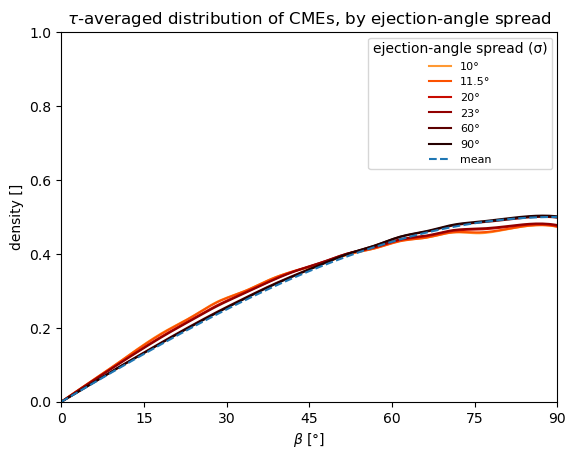

In [8]:
weights = np.sin(Taus)
weights = weights / weights.sum()

cmap = plt.get_cmap("gist_heat_r")
colors = cmap(np.linspace(0.2, 0.9, len(all_curves)))

for c, (deg, dens) in zip(colors, sorted(all_curves.items())):
    d_avg = np.average(dens, axis=0, weights=weights)
    smooth_curve = make_interp_spline(betas, d_avg / (np.average(d_avg) * np.pi))(x)
    plt.plot(x, smooth_curve, color=c, label=f"{deg}°")

plt.plot(x, np.sin(x) / 2, "--", color='tab:blue', label="mean")
plt.legend(title="ejection-angle spread (σ)", fontsize=8)
plt.xticks(np.linspace(0, np.pi / 2, 7), range(0, 91, 15))
plt.title(r"$\tau$-averaged distribution of CMEs, by ejection-angle spread")
plt.xlabel(r"$\beta$ [°]")
plt.ylabel(r"density []")
plt.xlim(0, np.pi / 2)
plt.ylim(0, 1)
plt.show()


**Take-away:** widening the ejection-angle spread does not shift CMEs towards lateral ejection — it
keeps the *typical* direction radial (`loc=0`) but randomises it more around the zenith. The two panels
above show that this randomisation pushes $\rho_\beta(\beta)$ *towards* the isotropic reference, not
away from it: the narrowest spread (10°, CMEs launched almost exactly radially) preserves the sharpest,
most structured suppression signature — the near-limb dip and the intermediate-to-large-$\beta$ bump
inherited directly from the flare/active-region latitude distribution — while the widest spreads
(60°, 90°) look nearly indistinguishable from the isotropic $\sin\beta$ curve, since a CME's direction
is then only weakly tied to its footpoint's latitude at all.

This is the opposite of what one might naively expect from a "wider ejection angle." It means the
geometric-suppression effect found in `CME_distribution.ipynb` is *most* pronounced for the tightly
radial ejection this model (and solar observations, $\sigma\approx11$-$30$°) actually motivate, and
would only wash out if CMEs on a given star were launched in near-random directions relative to their
local zenith ($\sigma\gtrsim60$°) — a regime with no physical motivation here. The main analysis's
near-radial assumption is therefore not just "not an artefact" of the suppression result, as originally
stated, but sits squarely in the regime where the effect is strongest.